# Structural robustness of mammalian transcription factor networks reveals plasticity across development

## Mouse Analysis

### External imports

In [2]:
import os
import pandas as pd
from io import BytesIO
import networkx as nx
from PIL import Image
import inspect
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from itertools import chain
import re
import time
import random

### Extracción de las redes

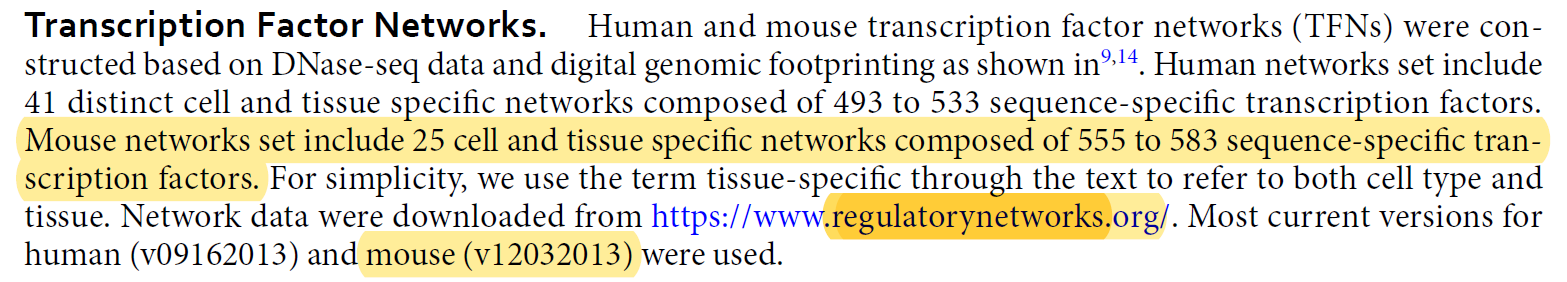

#### Auxiliar Fxns

In [3]:
def get_mouse_names(root, code_names):
    name = re.split('mouse_net', root)
    name = name[1]
    name = name.replace('/','')
    return code_names[name]

In [4]:
def extract_networks(directory_name=str, files_ignore=list, cols=tuple, feo=True, code_names=dict):
    networks = {}
    for root, dir, files in os.walk(directory_name):
        if len(files) != 0 and files[0] not in files_ignore:
          path = os.path.join(os.getcwd(), root, files[0])
          net = nx.DiGraph()
          if feo:
               f = np.genfromtxt(path, dtype= str, delimiter='\t', usecols= cols)
               net.add_edges_from(f)
          else:
               net = nx.read_edgelist(path)
          name = get_mouse_names(root, code_names)
          networks[name] = net
    return networks

#### Biological Networks

In [5]:
mm9CellTypeValues = { "m3134-DS8497" : 			  "mammary adenocarcinoma",
                        "m416B-DS14099" : 		  "CD34+ myeloid progenitor",
                        "mA20-DS16695" :            "B-lymphocyte reticulum cell sarcoma",
                        "mATn-DS17070" :            "activated T-naive cell",
                        "mATr-DS20149" :            "ATr",
                        "mB-DS16168" :              "B-cell, replicate 1",
                        "mB-DS17866" :              "B-cell, replicate 2",
                        "mBrain-DS12727" :          "normal brain",
                        "mCJ7-DS13320" :            "embryonic stem cells via 129S1/SVImJ mice",
                        "MEL-DS13036" :             "leukemia, K562 analog",
                        "mfBrain-DS14536" :         "fetal brain",
                        "mGenitalFatPad-DS18182" :  "genital adipose tissue",
                        "mHeart-DS18138" :          "normal heart",
                        "mKidney-DS13948" :         "normal kidney",
                        "mLiver-DS14605" :          "normal liver",
                        "mLung-DS14479" :           "normal lung",
                        "mNIH_3T3-DS16900" :        "fibroblast",
                        "mRetina-DS20004" :         "normal retina", 
                        "mThymus-DS18819" :         "normal thymus",
                        "mTN-DS16171" :             "TN, replicate 1",
                        "mTN-DS17080" :             "TN, replicate 2",
                        "mTR-DS17864" :             "regulatory T-cells",
                        "ZhBTc4-DS15236" :          "embryonic stem cells, +6 hrs doxycycline",
                        "ZhBTc4-DS17562" :          "embryonic stem cells, +24 hrs doxycycline",
                        "ZhBTc4-DS17616" :          "embryonic stem cells, control"
                        }

mouse_networks = extract_networks('./../../data/mouse_net/', [], (3,4), feo=True, code_names=mm9CellTypeValues)

In [9]:
for net_id, net in mouse_networks.items():
    name = net_id.replace(' ','_').replace(',','').replace('+','').replace('/','_') + '.txt'
    dir = './../../data/corrected_mouse_nets/'
    new_file = os.path.join(dir,name)

    with open(new_file, "w") as f:
        nx.write_edgelist(G= net, delimiter='\t', path= new_file, data= False)

#### Synthetic networks

ER and BA analogous ensembles to each biological network.

from freyrelab.nets import models

seed = 42
synth_graphs = {}

for net_id, G in mouse_networks.items():
    n = G.number_of_nodes()
    m = G.number_of_edges()
    for i in range(1,101):
        synth_graphs[f'BA_{net_id}_{i}'] = nx.DiGraph(models.barabasi_albert_graph(n))
        synth_graphs[f'ER_{net_id}_{i}'] = nx.erdos_renyi_graph(n, m/(n*(n-1)), seed=seed, directed=True)

networks = {**mouse_networks, **synth_graphs}

#### Graphs overall info

In [5]:
nets_info = {'Cell Type': [],
        'Nodes': [],
        'Edges': [],
        'Density': []
        }

for name,G in mouse_networks.items():
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = n_edges / (n_nodes * (n_nodes - 1))
    nets_info['Cell Type'].append(name)
    nets_info['Nodes'].append(n_nodes)
    nets_info['Edges'].append(n_edges)
    nets_info['Density'].append(density)

info_df = pd.DataFrame.from_dict(nets_info)
info_df

,Cell Type,Nodes,Edges,Density
0,mammary adenocarcinoma,568,22301,0.069246
1,CD34+ myeloid progenitor,570,18299,0.056421
2,B-lymphocyte reticulum cell sarcoma,571,20363,0.062565
3,activated T-naive cell,579,28185,0.084219
4,ATr,575,21445,0.064975
5,"B-cell, replicate 1",574,22119,0.067251
6,"B-cell, replicate 2",555,15565,0.050623
7,normal brain,562,15652,0.049644
8,embryonic stem cells via 129S1/SVImJ mice,579,20335,0.060763
9,"leukemia, K562 analog",568,20563,0.063849


### Netective Analysis

In [6]:
from netective.structure.structure import compare_structure

`!!!!AGUAS!!!!`

In [7]:
test = {
    net_name : net
    for i,(net_name, net) in enumerate(mouse_networks.items())
    if i < 2
}
test

{'mammary adenocarcinoma': <networkx.classes.digraph.DiGraph at 0x18d376eec40>,
 'CD34+ myeloid progenitor': <networkx.classes.digraph.DiGraph at 0x18d31ee7160>}

In [8]:
import networkx as nx
from netective import characterize_network
from netective.structure.structure import set_log_level

er_1 = nx.erdos_renyi_graph(n= 100, p=0.3, directed=True)
# characterize_network(er_1, verbose='debug')

In [9]:
mouse_networks

{'mammary adenocarcinoma': <networkx.classes.digraph.DiGraph at 0x18d376eec40>,
 'CD34+ myeloid progenitor': <networkx.classes.digraph.DiGraph at 0x18d31ee7160>,
 'B-lymphocyte reticulum cell sarcoma': <networkx.classes.digraph.DiGraph at 0x18d31eecd90>,
 'activated T-naive cell': <networkx.classes.digraph.DiGraph at 0x18d31ee71c0>,
 'ATr': <networkx.classes.digraph.DiGraph at 0x18d31eec8e0>,
 'B-cell, replicate 1': <networkx.classes.digraph.DiGraph at 0x18d31ee7640>,
 'B-cell, replicate 2': <networkx.classes.digraph.DiGraph at 0x18d31ef4f40>,
 'normal brain': <networkx.classes.digraph.DiGraph at 0x18d31ee2550>,
 'embryonic stem cells via 129S1/SVImJ mice': <networkx.classes.digraph.DiGraph at 0x18d31ef4af0>,
 'leukemia, K562 analog': <networkx.classes.digraph.DiGraph at 0x18d31ee2fa0>,
 'fetal brain': <networkx.classes.digraph.DiGraph at 0x18d31eecee0>,
 'genital adipose tissue': <networkx.classes.digraph.DiGraph at 0x18d31ee2f40>,
 'normal heart': <networkx.classes.digraph.DiGraph at

In [19]:
mouse_networks['mammary adenocarcinoma'].number_of_nodes(), mouse_networks['mammary adenocarcinoma'].number_of_edges()

(568, 22301)

In [17]:
from netective.structure.timed_structure import Structure as structure_timed
from netective.structure.structure import Structure
struct_3 = structure_timed(mouse_networks['mammary adenocarcinoma'], norm=None, net_id= 'og structure', verbose= 'critical')
s, d, t = struct_3.get_props()
s

{'og structure': {'Average Local Efficiency': 0.656353932128416,
  'Average Shortest Path Length': 2.0375959460466504,
  'Center': 11,
  'Diameter': 4,
  'Global Efficiency': 0.5374619113860114,
  'Periphery': 97,
  'Radius': 2,
  'Complex Feed-Forward Circuits': 23959,
  'Feed-Forward Circuits': 239460,
  '3-Feedback Loops': 40978,
  'Entropy of Degree Distribution': 7.138355558988448,
  'Max Degree': 343,
  'Number of Edges': 21059,
  'Number of Nodes': 568,
  'Self-Loops': 89,
  'Undirected Gini Index': 0.4893580343354582,
  'Density': 0.06912380975996826,
  'Entropy of Out-Degree Distribution': 5.2570483156206596,
  'Gini Index': 0.5723501472491288,
  'Max In-Dregree': 307,
  'Max Out-Degree': 199,
  'Number of Arcs': 22301,
  'Regulators': 366,
  'Self Regulations': 89,
  'Gene % in the Giant Component': 568,
  'Undirected Density': 0.06527412715731006}}

In [14]:
from netective.structure.timed_structure import Structure as structure_timed
from netective.structure.structure import Structure
import networkx as nx

net = nx.erdos_renyi_graph(n= 100, p=0.2, directed=True)

struct_1 = structure_timed(mouse_networks['mammary adenocarcinoma'], norm=None, net_id= 'timed_structured', verbose= 'critical')
struct_2 = Structure(mouse_networks['mammary adenocarcinoma'], norm=None, net_id= 'og structure', verbose= 'critical')

scalar_values_1, dist_props_1, process_times = struct_1.get_props()
scalar_values_2, dist_props_2 = struct_2.get_props()

scalar_values_1, scalar_values_2


({'timed_structured': {'Average Local Efficiency': 0.656353932128416,
   'Average Shortest Path Length': 2.0375959460466504,
   'Center': 11,
   'Diameter': 4,
   'Global Efficiency': 0.5374619113860114,
   'Periphery': 97,
   'Radius': 2,
   'Complex Feed-Forward Circuits': 23959,
   'Feed-Forward Circuits': 239460,
   '3-Feedback Loops': 40978,
   'Entropy of Degree Distribution': 7.138355558988448,
   'Max Degree': 343,
   'Number of Edges': 21059,
   'Number of Nodes': 568,
   'Self-Loops': 89,
   'Undirected Gini Index': 0.4893580343354582,
   'Density': 0.06912380975996826,
   'Entropy of Out-Degree Distribution': 5.2570483156206596,
   'Gini Index': 0.5723501472491288,
   'Max In-Dregree': 307,
   'Max Out-Degree': 199,
   'Number of Arcs': 22301,
   'Regulators': 366,
   'Self Regulations': 89,
   'Gene % in the Giant Component': 568,
   'Undirected Density': 0.06527412715731006}},
 {'og structure': {'Average Local Efficiency': 0.656353932128416,
   'Average Shortest Path Lengt

In [12]:
distribuciones = {
    'net_1' : {
        'Out Degree' : [1,2,3,4],
        'In Degree' : [5,6,7,8],
        'Degree' : [9,10,11,12]
    },
    'net_2' : {
        'Out Degree' : [1,2,3,4],
        'In Degree' : [5,6,7,8],
        'Degree' : [9,10,11,12]
    }
}

properties = {}
for i, (net_name, prop)  in enumerate(distribuciones.items()):
    for j, (prop_name, values) in enumerate(prop.items()):
        if i == 0:
            properties[prop_name] = {
                'Average' : [],
                'Variation' : [],
                'Skewness' : [],
                'Kurtosis' : []
            }
        for k, value in enumerate(values):
            if k == 0:
                moment = 'Average'
            elif k == 1:
                moment = 'Variation'
            elif k == 2:
                moment = 'Skewness'
            elif k == 3:
                moment = 'Kurtosis'
            properties[prop_name][moment].append(value)

properties


{'Out Degree': {'Average': [1, 1],
  'Variation': [2, 2],
  'Skewness': [3, 3],
  'Kurtosis': [4, 4]},
 'In Degree': {'Average': [5, 5],
  'Variation': [6, 6],
  'Skewness': [7, 7],
  'Kurtosis': [8, 8]},
 'Degree': {'Average': [9, 9],
  'Variation': [10, 10],
  'Skewness': [11, 11],
  'Kurtosis': [12, 12]}}

In [13]:
final = {}
for prop_name, moments in properties.items():
    final[prop_name] = []
    for moment, values in moments.items():
        avg = sum(values) / len(values)
        final[prop_name].append(avg)
final

{'Out Degree': [1.0, 2.0, 3.0, 4.0],
 'In Degree': [5.0, 6.0, 7.0, 8.0],
 'Degree': [9.0, 10.0, 11.0, 12.0]}

In [41]:
from netective import compare_structure
import networkx as nx
from scipy.stats import spearmanr


my_properties = ['Complex Feed-Forward Circuits', 'Feed-Forward Circuits', '3-Feedback Loops']
nets = {
    'net_1' : nx.erdos_renyi_graph(n= 100, p=0.2, directed=True),
    'net_2' : nx.erdos_renyi_graph(n= 100, p=0.2, directed=True)
}
a,b = compare_structure(nets, workers=2, association_metric=spearmanr, return_prop_dicts= True, erdos_renyi= 2, verbose= 'debug');


[INFO] Starting analysis of inputed networks...


  0%|          | 0/2 [00:00<?, ?it/s]

[INFO] Running net_1...
[INFO] Running net_2...


[INFO] Finilized: net_2


 50%|█████     | 1/2 [00:03<00:03,  3.31s/it]

[INFO] Finilized: net_1


100%|██████████| 2/2 [00:03<00:00,  1.89s/it]


In [36]:
for net_name, props in a.items():
    print(net_name, len(props))

net_1 70
net_2 70
net_1_Avg_ER 70
net_2_Avg_ER 70


In [ ]:
from netective import compare_structure
import networkx as nx
from scipy.stats import spearmanr, pearsonr

# Let's create a random network to characterize
G = nx.erdos_renyi_graph(100, 0.3, directed=True)
# Let's create a second network to compare to the first one.
H = nx.path_graph(50, create_using=nx.DiGraph)

# Comparing both networks is as simple as calling the function with a dictionary of networks.
networks = {"my_network_G": G, "my_network_H": H}
my_properties = ['Complex Feed-Forward Circuits', 'Feed-Forward Circuits', '3-Feedback Loops']

compare_structure(networks, workers=2, selected_props= my_properties, return_prop_dicts= False, association_metric= pearsonr, verbose= 'critical');

In [1]:
from netective.utils import parse_network
import os

networks = {}
nets_path = 'H:\\Mi unidad\\Respaldo\\Genomicas\\netective\\data\\test_comp'
nets_path = './../../data/test_comp/'
comments = '#'
delimiter = '\t'
for root, dir, files in os.walk(nets_path):
    if len(files) != 0:
        for net_name in files:
            net_path = os.path.join(os.getcwd(), root, net_name)
            networks[net_name] = parse_network(net_path, comments, delimiter)


100%|██████████| 3/3 [00:29<00:00,  9.73s/it]


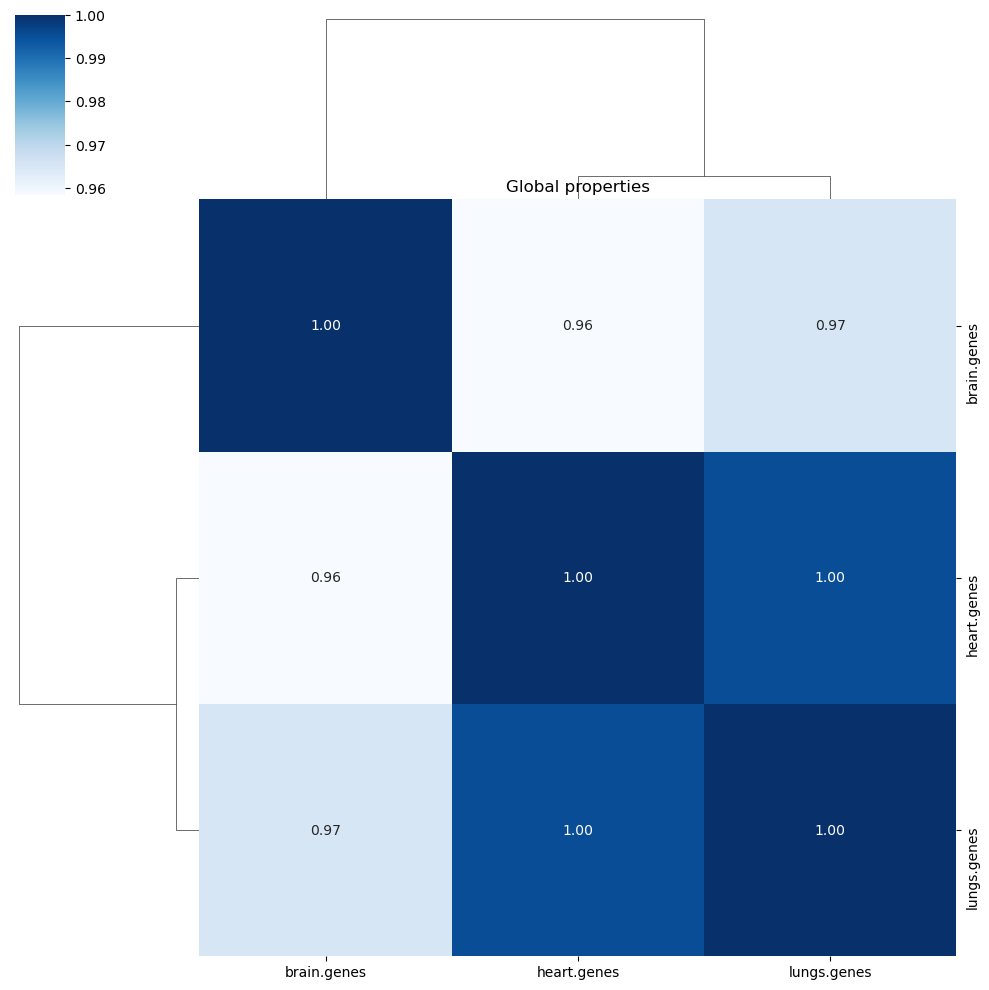

In [2]:
from netective.utils import save_figs
from netective import compare_structure
fig = compare_structure(networks= networks, norm= 'network');

In [8]:
save_figs(fig)

In [3]:
a = {}

b = {
    'net_1' : {
        'prop_1' : [1],
        'prop_2' : [2]
    }
}

a.update(b)
print(a)

c = {
    'net_2' : {
        'prop_1' : [1],
        'prop_2' : [2]
    }
}
a.update(c)
print(a)

{'net_1': {'prop_1': [1], 'prop_2': [2]}}
{'net_1': {'prop_1': [1], 'prop_2': [2]}, 'net_2': {'prop_1': [1], 'prop_2': [2]}}


In [83]:
x = [0,1,2,3,4,5,6,7,8,9,10]
y = [0,1,2,3]
z = [0,1,2,3,4]
test = z
workers = 5
foo = []
completed = 0
final = []

for num in test:
    foo.append(num)
    if (len(foo) == workers or completed == len(test) // workers) and len(test) > workers:
        print(foo)
        foo = []
        completed += 1
if len(test) <= workers:
    print(foo)

[0, 1, 2, 3, 4]


In [31]:
import networkx as nx

for i in range(11):
    net = nx.erdos_renyi_graph(100, 0.2, directed= True)
    print(net.number_of_nodes(), net.number_of_edges())
    nx.write_edgelist(net, f'./../../data/er_test/{i}_net.txt', data= False, delimiter='\t')
    foo = nx.read_edgelist(f'./../../data/er_test/{i}_net.txt', create_using= nx.DiGraph)
    print(foo.number_of_edges())


100 2083
2083
100 2005
2005
100 2020
2020
100 1997
1997
100 1969
1969
100 1977
1977
100 1936
1936
100 2017
2017
100 2052
2052
100 1976
1976
100 1956
1956


In [44]:
import os
import networkx as nx
def sort_nets(nets_path: str):
    files_paths = []
    for root, dir, files in os.walk(nets_path):
        if len(files) != 0:
            for f in files:
                files_paths.append(os.path.join(nets_path,f))
    files_paths = sorted (
        files_paths,
        key = lambda x: os.stat(x).st_size,
        reverse=True
    )
    for name_of_file in files_paths: 
        size_of_file  = os.stat(name_of_file).st_size  
        print(size_of_file, ' -->', name_of_file)
        
    return files_paths

foo = sort_nets(nets_path= './../../data/test_comp/')
for f in foo:
    net = nx.read_edgelist(path= f, delimiter='\t', create_using= nx.DiGraph)
    net_id = os.path.basename(f)
    print(f, net, net_id)


./../../data/test_comp/lungs.genes DiGraph with 532 nodes and 17823 edges lungs.genes
./../../data/test_comp/heart.genes DiGraph with 516 nodes and 14295 edges heart.genes
./../../data/test_comp/brain.genes DiGraph with 519 nodes and 11698 edges brain.genes


(<Figure size 200x780 with 1 Axes>, <Figure size 1200x750 with 11 Axes>)

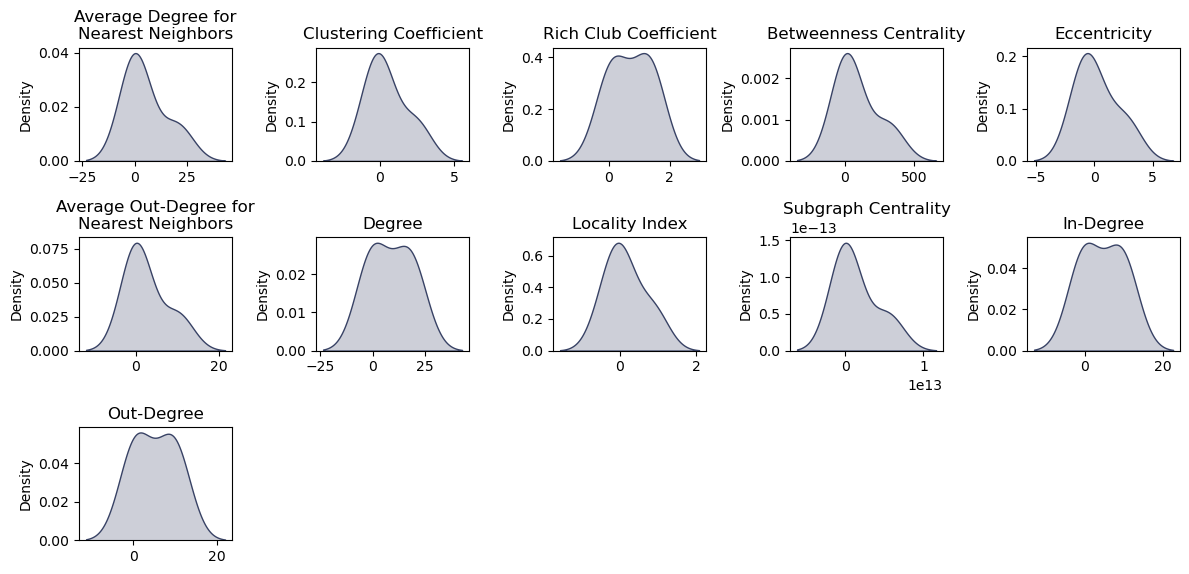

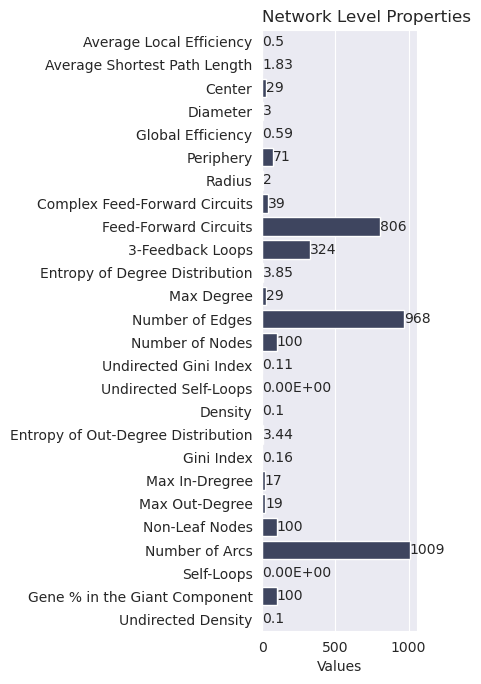

In [1]:
import networkx as nx
from netective import characterize_network

net = nx.erdos_renyi_graph(100, 0.1, directed=True)

characterize_network(net)

(<Figure size 200x690 with 1 Axes>, <Figure size 1200x750 with 11 Axes>)

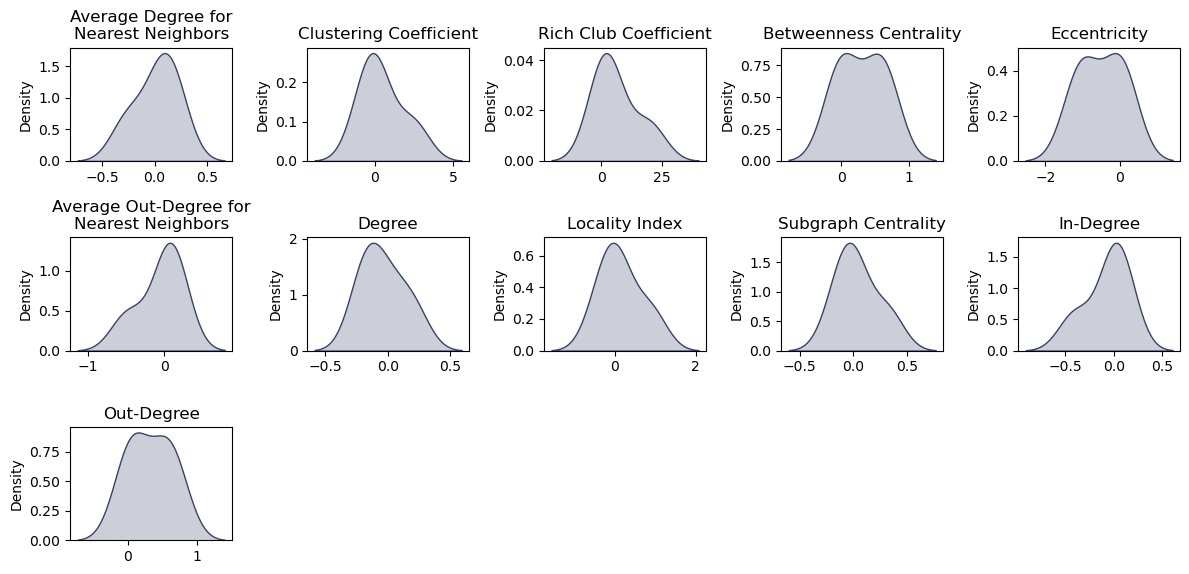

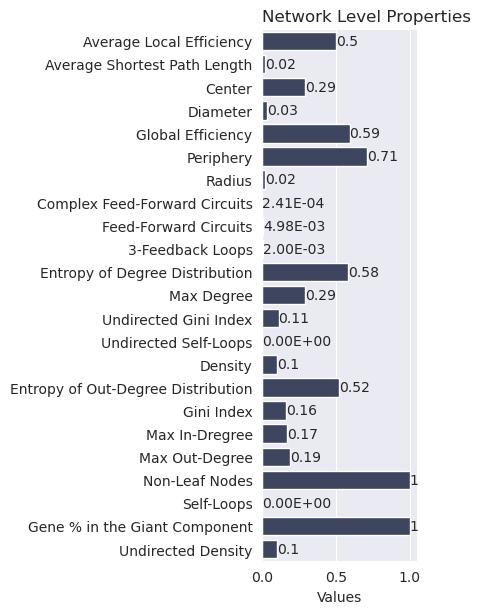

In [2]:
characterize_network(net, norm='network')

(<Figure size 200x690 with 1 Axes>, <Figure size 1200x750 with 11 Axes>)

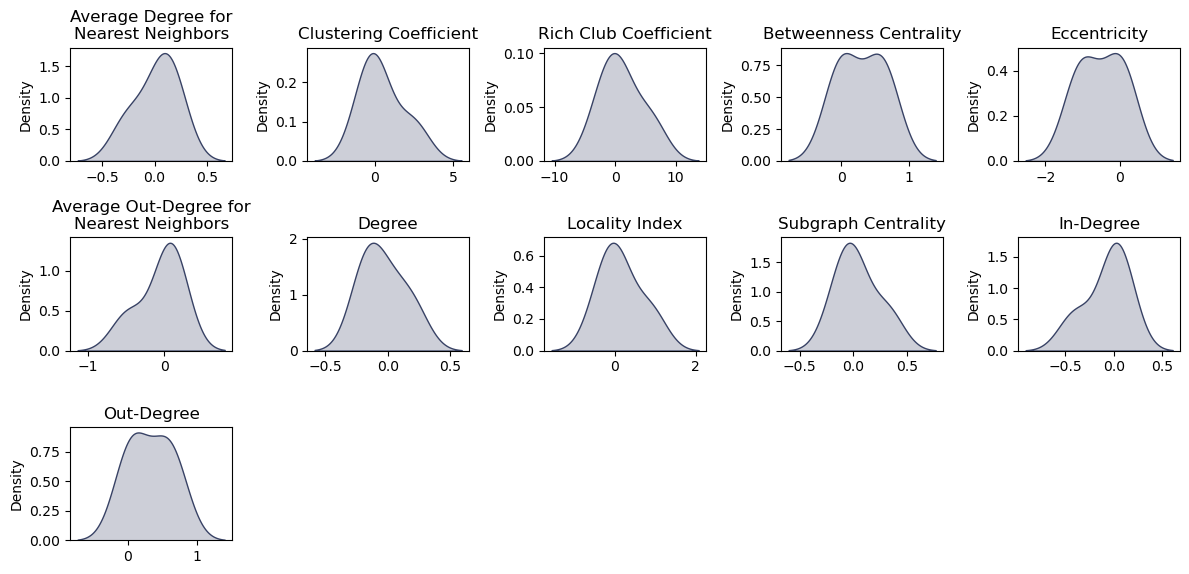

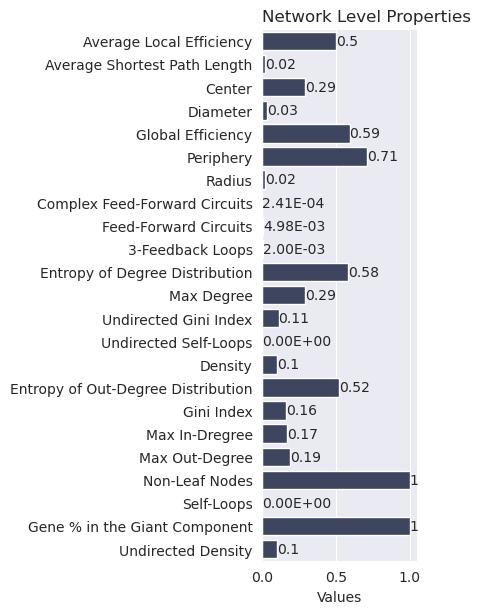

In [3]:
characterize_network(net, norm='biological')